# Fine-Tuning de Análise de Sentimentos em Português
Este notebook demonstra como fizemos e serve como um guia para realizar o ajuste fino (fine-tuning) do modelo **Qwen 3.5 0.8B** para a tarefa de classificação de sentimentos em português (positivo, negativo ou neutro) utilizando a interface visual **Unsloth Studio**.

O pipeline é composto por:
1. Organização do ambiente e preparação dos dados (balanceamento e limpeza).
2. Configuração e treinamento do modelo no Unsloth Studio.
3. Avaliação de desempenho local e teste de *domain shift* (desvio de domínio) usando a base `tweetsentbr_fewshot` do Hugging Face.
4. Geração de gráficos de acurácia comparativos.

---

#### Download das dependencias, datasets e do Unsloth Studio

In [1]:
# Este código vai clonar o repositório e rodar o setup do Unsloth Sudio no Colab,
# para rodar localmente, consulte documentação
!git clone --depth 1 --branch main https://github.com/unslothai/unsloth.git
%cd /content/unsloth
!chmod +x studio/setup.sh && ./studio/setup.sh --local
!pip install --upgrade git+https://github.com/huggingface/transformers.git

Cloning into 'unsloth'...
remote: Enumerating objects: 1921, done.
remote: Counting objects: 100% (1921/1921), done.
remote: Compressing objects: 100% (1725/1725), done.
remote: Total 1921 (delta 206), reused 1058 (delta 170), pack-reused 0 (from 0)
Receiving objects: 100% (1921/1921), 37.96 MiB | 27.98 MiB/s, done.
Resolving deltas: 100% (206/206), done.
/content/unsloth

  🦥 Unsloth Studio Setup
  ────────────────────────────────────────────────────
                 local mode: overlaying /content/unsloth (editable) + unsloth-zoo from git main
                 upgrading npm...
  node           v20.19.0 | npm 11.17.0
                 installing bun...
                 bun installed (1.3.14)
                 building frontend...
                 using bun for package install (faster)
  frontend       built
                 Colab detected, installing Studio backend dependencies...
  python         backend deps installed into system Python
                 continuing to llama.cpp install

In [1]:
import os
import kagglehub
from kagglehub import KaggleDatasetAdapter

# 1. Definir e criar a pasta "datasets"
os.makedirs("datasets", exist_ok=True)
gemini_path = "datasets/gemini.csv"
pt_br_path = "datasets/sentiment_analysis_pt_br.csv"

# 2. Baixar e salvar o dataset de sentimentos em PT-BR
if not os.path.exists(pt_br_path):
    print("Baixando dataset 'anlise-de-sentimentos-pt-br'...")
    df_pt = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "gazprom/anlise-de-sentimentos-pt-br",
        "sentiment_analysis_pt_br.csv"
    )
    df_pt.to_csv(pt_br_path, index=False, encoding="utf-8")

# 3. Baixar e salvar o dataset do Gemini
if not os.path.exists(gemini_path):
    print("Baixando dataset 'dataset-para-anlise-de-sentimentos-gemini'...")
    df_gem = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "rogesgrandi/dataset-para-anlise-de-sentimentos-gemini",
        "gemini.csv"
    )
    df_gem.to_csv(gemini_path, index=False, encoding="utf-8")

print("Datasets prontos e salvos na pasta 'unsloth/datasets/'.")

Baixando dataset 'anlise-de-sentimentos-pt-br'...


/tmp/ipykernel_2902/4017318995.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_pt = kagglehub.load_dataset(


100%|██████████| 816k/816k [00:01<00:00, 651kB/s]
/tmp/ipykernel_2902/4017318995.py:23: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_gem = kagglehub.load_dataset(


Baixando dataset 'dataset-para-anlise-de-sentimentos-gemini'...


100%|██████████| 71.2k/71.2k [00:00<00:00, 250kB/s]

Datasets prontos e salvos na pasta 'unsloth/datasets/'.


### Preparação dos Dados (Limpeza e Balanceamento)

Trabalharemos com os datasets:
- **gemini.csv**: Dataset sintético gerado via API do Gemini contendo sentenças curtas e sua classificação.
- **sentiment_analysis_pt_br.csv**: Dataset generalista em português adaptado de bases públicas.

Aqui cosntruimos um dataset de treino de **1.998 amostras** (~2.000), extraindo **999 amostras equilibradas** de cada um dos dois datasets (333 positivo, 333 negativo e 333 neutro por base).
O dataset de teste local será feito com **999 amostras equilibradas**, utilizando a sobra de dados do Gemini e complementando de forma estratificada com o Sentiment Analysis PT-BR.

In [2]:
import pandas as pd
import numpy as np
import os

def fix_mojibake(text):
    if not isinstance(text, str):
        return ""
    try:
        if any(sig in text for sig in ['Ã¡', 'Ã©', 'Ã­', 'Ã³', 'Ãº', 'Ã£', 'Ãµ', 'Ã§', 'Ã ', 'Ã‰', 'Ã“', 'Ã‡']):
            return text.encode('cp1252').decode('utf-8')
    except (UnicodeEncodeError, UnicodeDecodeError):
        try:
            return text.encode('latin-1').decode('utf-8')
        except Exception:
            pass
    return text

datasets_dir = "datasets"
os.makedirs(datasets_dir, exist_ok=True)
gemini_path = os.path.join(datasets_dir, "gemini.csv")
pt_br_path = os.path.join(datasets_dir, "sentiment_analysis_pt_br.csv")

print("Carregando e tratando as bases...")
df_gem = pd.read_csv(gemini_path)
df_gem.columns = [c.strip() for c in df_gem.columns]
df_gem = df_gem.rename(columns={"texto": "TEXTO", "sentimento": "SENTIMENTO"})
df_gem["SENTIMENTO"] = df_gem["SENTIMENTO"].str.lower().str.strip()
df_gem["TEXTO"] = df_gem["TEXTO"].apply(fix_mojibake)

df_pt = pd.read_csv(pt_br_path)
df_pt.columns = [c.strip() for c in df_pt.columns]
df_pt = df_pt.rename(columns={"Sentence": "TEXTO", "Sentiment": "SENTIMENTO"})
df_pt["SENTIMENTO"] = df_pt["SENTIMENTO"].str.lower().str.strip()
df_pt["TEXTO"] = df_pt["TEXTO"].apply(fix_mojibake)

# Divisão estratificada - Gemini
train_gem_list = []
test_gem_list = []
for sentiment in ["positivo", "negativo", "neutro"]:
    df_sub = df_gem[df_gem["SENTIMENTO"] == sentiment].copy()
    df_sub = df_sub.sample(frac=1, random_state=42).reset_index(drop=True)
    train_gem_list.append(df_sub.iloc[:333])
    test_gem_list.append(df_sub.iloc[333:])

df_train_gem = pd.concat(train_gem_list)
df_test_gem_leftover = pd.concat(test_gem_list)

# Divisão estratificada - PT-BR
train_pt_list = []
test_pt_list = []
map_sentiment = {"positive": "positivo", "negative": "negativo", "neutral": "neutro",
                 "positivo": "positivo", "negativo": "negativo", "neutro": "neutro"}
for sentiment in ["positivo", "negativo", "neutro"]:
    df_sub = df_pt[df_pt["SENTIMENTO"].map(map_sentiment) == sentiment].copy()
    df_sub["SENTIMENTO"] = sentiment
    df_sub = df_sub.sample(frac=1, random_state=42).reset_index(drop=True)
    train_pt_list.append(df_sub.iloc[:333])
    test_pt_list.append(df_sub.iloc[333:])

df_train_pt = pd.concat(train_pt_list)
df_test_pt_leftover = pd.concat(test_pt_list)

# Prompts
system_prompt = "Você é um classificador de análise de sentimentos em português. Analise o texto do usuário e responda com o rótulo final (positivo, negativo ou neutro)."
user_template = 'Classifique o sentimento deste texto: "{}"'

# 1. Gerar Treino SFT
df_train_raw = pd.concat([df_train_gem, df_train_pt]).sample(frac=1, random_state=42)
df_train_sft = pd.DataFrame({
    "system": system_prompt,
    "user": df_train_raw["TEXTO"].apply(lambda t: user_template.format(t)),
    "assistant": df_train_raw["SENTIMENTO"]
})
df_train_sft.to_csv(os.path.join(datasets_dir, "train_sft.csv"), index=False, encoding="utf-8")

# 2. Gerar Teste Final Equilibrado (999 amostras)
test_final_list = []
for sentiment in ["positivo", "negativo", "neutro"]:
    df_g = df_test_gem_leftover[df_test_gem_leftover["SENTIMENTO"] == sentiment].copy()
    needed = 333 - len(df_g)
    df_p = df_test_pt_leftover[df_test_pt_leftover["SENTIMENTO"] == sentiment].sample(n=needed, random_state=42)
    test_final_list.append(pd.concat([df_g, df_p]))

df_test_raw = pd.concat(test_final_list).sample(frac=1, random_state=42)

# Dataset Teste Full (System, User, Assistant)
df_test_full = pd.DataFrame({
    "system": system_prompt,
    "user": df_test_raw["TEXTO"].apply(lambda t: user_template.format(t)),
    "assistant": df_test_raw["SENTIMENTO"]
})
df_test_full.to_csv(os.path.join(datasets_dir, "test_final.csv"), index=False, encoding="utf-8")

# Dataset Teste No-System (User, Assistant)
df_test_no_system = df_test_full[["user", "assistant"]].copy()
df_test_no_system.to_csv(os.path.join(datasets_dir, "test_final-noSystem.csv"), index=False, encoding="utf-8")

print(f"-> Treino salvo: {len(df_train_sft)} linhas")
print(f"-> Teste Full salvo: {len(df_test_full)} linhas")
print(f"-> Teste No-System salvo: {len(df_test_no_system)} linhas")

Carregando e tratando as bases...
-> Treino salvo: 1998 linhas
-> Teste Full salvo: 999 linhas
-> Teste No-System salvo: 999 linhas


## Treinamento no Unsloth Studio

Como a inicialização do Unsloth Studio inicia um servidor que roda em background, o tutorial abaixo é um "guia" pela interface e configurações necessárias para realizar o fine-tuning que fizemos:

### 1. Tela Inicial do Unsloth Studio
Esta é a interface inicial do painel. Há uma seta apontando para a opção 'Train' no menu lateral esquerdo, onde iremos para iniciar a configuração do treinamento do modelo.
![1. Tela Inicial](https://raw.githubusercontent.com/ClassNeuralNetwork/sentiment-analysis-qwen-unsloth/main/imgs/1.%20tela-inicial-unsloth-studio.png)

### 2. Seleção de Modelo
Selecione o modelo LLM base. Para o nosso experimento, usamos o **Qwen3.5 0.8B** (que oferece excelente desempenho em português com baixo consumo de recursos).
![2. Seleção de Modelo](https://raw.githubusercontent.com/ClassNeuralNetwork/sentiment-analysis-qwen-unsloth/main/imgs/2.%20tela-selecao-de-modelo.png)

### 3. Seleção do Método de Treinamento
Selecione a técnica de treinamento. Utilizaremos o **QLoRA de 4 bits**, ideal para acelerar o processo e reduzir o consumo de memória GPU. Observação: especificamente para este exemplo com o modelo **Qwen 3.5 0.8B** escolhido, é possível realizar o treinamento com apenas **6 GB de VRAM** utilizando este método.
![3. Método de Treinamento](https://raw.githubusercontent.com/ClassNeuralNetwork/sentiment-analysis-qwen-unsloth/main/imgs/3.%20tela-selecao-de-metodo.png)

### 4. Seleção e Upload do Dataset
Faça o upload dos arquivos `train_sft.csv` e `test_final.csv` que geramos na Etapa 2 (está na pasta `unsloth/datasets/` ou `datasets/`).
![4. Seleção do Dataset](https://raw.githubusercontent.com/ClassNeuralNetwork/sentiment-analysis-qwen-unsloth/main/imgs/4.%20tela-selecao-dataset-local.png)

### 5. Configuração de Hiperparâmetros
Configure os parâmetros de treinamento. No nosso ajuste:
- Defina as iterações para usar **Épocas (Epochs)** com o valor **1**.
- Tamanho do contexto: **512**.
- Batch Size: **4**.
- Deixamos os demais valores nos padrões recomendados do Studio.
![5. Hiperparâmetros](https://raw.githubusercontent.com/ClassNeuralNetwork/sentiment-analysis-qwen-unsloth/main/imgs/5.%20tela-selecao-hyperparametros.png)

### 6. Mapeamento de Colunas do Dataset
Ao iniciar o treinamento, valide o mapeamento dos campos. Associe as colunas do arquivo CSV às mensagens do ChatML:
- **System**: Coluna `system`
- **User**: Coluna `user`
- **Assistant**: Coluna `assistant`
![6. Mapeamento](https://raw.githubusercontent.com/ClassNeuralNetwork/sentiment-analysis-qwen-unsloth/main/imgs/6.%20tela-iniciar-treino.png)

### 7. Inicialização do Treino
Confirmado o mapeamento, o Unsloth Studio iniciará o download do modelo base e o loop de treinamento.
![7. Download e Treinamento](https://raw.githubusercontent.com/ClassNeuralNetwork/sentiment-analysis-qwen-unsloth/main/imgs/7.%20tela-inicializacao-treino.png)

### 8. Etapa de treinamento
A inteface de treinamento do Unsloth Studio exibirá informações do sistema durante a execução do treino.
![8. Etapa de Treinamento](https://raw.githubusercontent.com/ClassNeuralNetwork/sentiment-analysis-qwen-unsloth/main/imgs/8.%20tela-treinamento-em-execucao.png)

### 9. Finalização do treino
Quando o treinamento acabar, será exibido um botão para exportação do modelo.
![9. Treinamento finalizado](https://raw.githubusercontent.com/ClassNeuralNetwork/sentiment-analysis-qwen-unsloth/main/imgs/9.%20tela-de-treinamento-finalizado.png)

### 10. Exportação do modelo
Na tela de exportação, selecione o modelo que quiser salvar ou exportar no dropdown, será exibido diversos checkpoints do modelo que foram salvos durante o treinamento.
![10. Exportação do modelo](https://raw.githubusercontent.com/ClassNeuralNetwork/sentiment-analysis-qwen-unsloth/main/imgs/10.%20tela-de-exportacao-de-modelo.png)

### 11. Exportação para Huggingface
Selecione a opção "Push to Hub" para fazer o envio automatico do modelo para seu repositorio no Huggingface, ao inserir seu nome e o nome do modelo que achar melhor juntamente com o token do HF, será possivel salvar de forma privada ou publica. Para este teste, salvaremos publicamente.
![11. Exportação para o HF](https://raw.githubusercontent.com/ClassNeuralNetwork/sentiment-analysis-qwen-unsloth/main/imgs/11.%20tela-de-exportacao-huggingface-opcional.png)

### 12. Exportação local
Recomendamos salvar o modelo localmente caso voce esteja executando o Unsloth Studio localmente na sua maquina.
![12. Exportação local](https://raw.githubusercontent.com/ClassNeuralNetwork/sentiment-analysis-qwen-unsloth/main/imgs/12.%20tela-de-exportacao-local.png)

---


In [ ]:
# INICIAR SERVIDOR DO UNSLOTH STUDIO
import sys
sys.path.insert(0, "/content/unsloth/studio/backend")
from colab import start
start()
# Após a inicialização, será pedido para criar uma senha.

## Avaliação de Desempenho e Geração de Gráficos

Após a conclusão do treinamento no Unsloth Studio, o modelo ajustado estará salvo como um checkpoint na pasta de exportação ou no Huggingface.

Nesta seção, realizaremos a inferência em lote comparando:
1. **Modelo Causal Base**: O Qwen 3.5 0.8B original sem fine-tuning.
2. **Modelo SFT Ajustado**: O modelo que passou pelo fine-tuning no Unsloth Studio.

Avaliaremos:
- **Teste Local**: No dataset equilibrado `test_final.csv`.
- **Teste de Domain Shift (Desvio de Domínio)**: Utilizando o dataset `eduagarcia/tweetsentbr_fewshot` do Hugging Face.

In [ ]:
import os
import gc
import sys
import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

# ======================================================================
# CONFIGURAÇÃO DE MODELOS (VIA HUGGING FACE)
# ======================================================================

base_model_name = "unsloth/Qwen3.5-0.8B"
# O modelo abaixo foi o treinado durante essas intruções
ft_model_path = "Caueh/Qwen3.5-0.8B-Sentiment-SFT-ptbr"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Rodando inferência em: {device.upper()}")
print(f"Modelo Base: {base_model_name}")
print(f"Modelo SFT (Hugging Face): {ft_model_path}")

system_prompt = "Você é um classificador de análise de sentimentos em português. Analise o texto do usuário e responda com o rótulo final (positivo, negativo ou neutro)."
user_template = 'Classifique o sentimento deste texto: "{}"'

def clean_output(pred_str):
    # Remove ChatML tokens, EOS e possíveis tags de pensamento/thinking
    clean_part = pred_str.lower().strip()
    for tag in ["<|im_end|>", "<|endoftext|>", "<thought>", "</thought>", "<|thought|>", "<think>", "</think>", "<|think|>", "<|im_start|>"]:
        clean_part = clean_part.replace(tag, "")

    clean_part = clean_part.strip()
    if "positivo" in clean_part or "positive" in clean_part: return "positivo"
    elif "negativo" in clean_part or "negative" in clean_part: return "negativo"
    elif "neutro" in clean_part or "neutral" in clean_part: return "neutro"
    return "desconhecido"

def evaluate_model(model_path, model_label, sentences, true_labels, batch_size=32):
    print(f"\nAvaliando: {model_label}...")
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    tokenizer.padding_side = 'left'
    tokenizer.pad_token = tokenizer.eos_token
    # Template ChatML: adiciona tags de pensamento fechadas no assistant prompt
    # para evitar que o modelo gaste tokens pensando durante a inferência (diminui latência
    # e foi como treinamos o modelo para responder)
    tokenizer.chat_template = "{% for message in messages %}{{'<|im_start|>' + message['role'] + '\n' + message['content'] + '<|im_end|>\n'}}{% endfor %}{% if add_generation_prompt %}{{ '<|im_start|>assistant\n<think>\n</think>\n' }}{% endif %}"

    try:
        model = AutoModelForCausalLM.from_pretrained(
            model_path,
            torch_dtype=torch.float16 if device == "cuda" else torch.float32,
            device_map="auto"
        )
    except Exception as e:
        print(f"Erro ao carregar modelo: {e}")
        return {"overall_acc": 0.0, "class_acc": {"positivo": 0.0, "negativo": 0.0, "neutro": 0.0}}

    model.eval()
    prompts = [tokenizer.apply_chat_template([{"role": "system", "content": system_prompt}, {"role": "user", "content": user_template.format(s)}], tokenize=False, add_generation_prompt=True) for s in sentences]

    predictions = []
    for i in range(0, len(prompts), batch_size):
        batch = prompts[i : i + batch_size]
        inputs = tokenizer(batch, padding=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=10,
                pad_token_id=tokenizer.eos_token_id,
                temperature=0.1,
                top_p=0.9
            )
        for j, out in enumerate(outputs):
            pred_str = tokenizer.decode(out[inputs.input_ids.shape[1]:], skip_special_tokens=False)
            predictions.append(clean_output(pred_str))

    overall_acc = sum(1 for p, t in zip(predictions, true_labels) if p == t) / len(true_labels)
    class_acc = {c: (sum(1 for j, val in enumerate(true_labels) if val == c and predictions[j] == c) / max(1, true_labels.count(c))) for c in ["positivo", "negativo", "neutro"]}

    del model, tokenizer
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {"overall_acc": overall_acc, "class_acc": class_acc}


Rodando inferência em: CUDA
Modelo Base: unsloth/Qwen3.5-0.8B
Modelo SFT (Hugging Face): Caueh/Qwen3.5-0.8B-Sentiment-SFT-ptbr


Iniciando Teste Local...

Avaliando: Qwen 3.5 Base - Local...


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]


Avaliando: Qwen 3.5 SFT - Local...


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]


Carregando dataset de Domain Shift (tweetsentbr_fewshot) do Hugging Face...

Avaliando: Qwen 3.5 Base - Domain Shift...


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]


Avaliando: Qwen 3.5 SFT - Domain Shift...


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

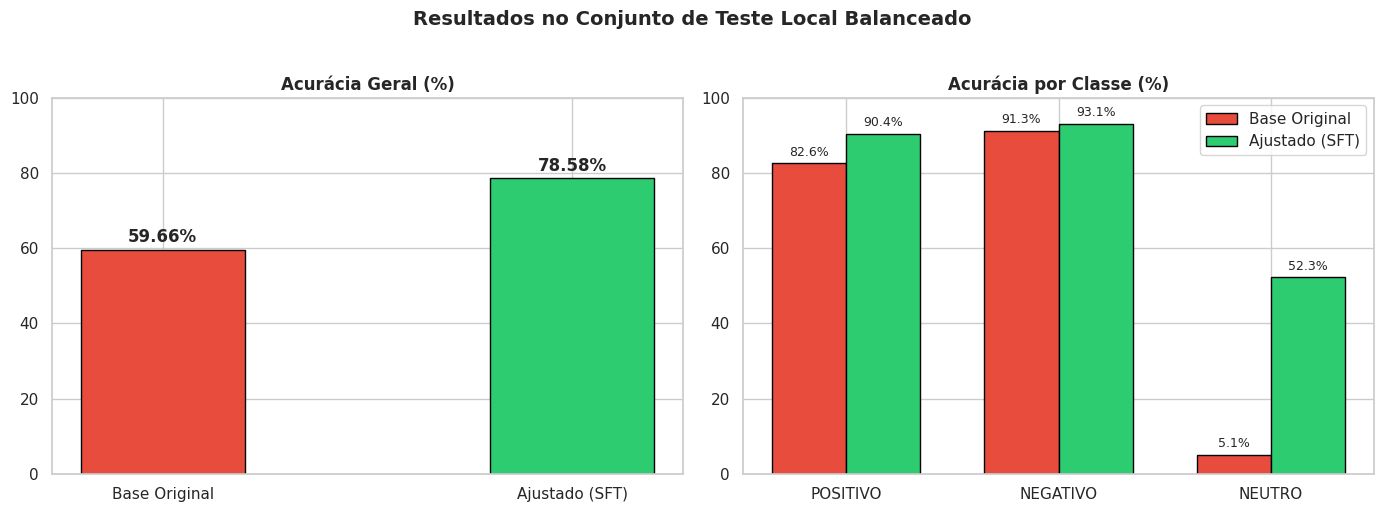

Gráfico salvo em: benchmark_local_results.png


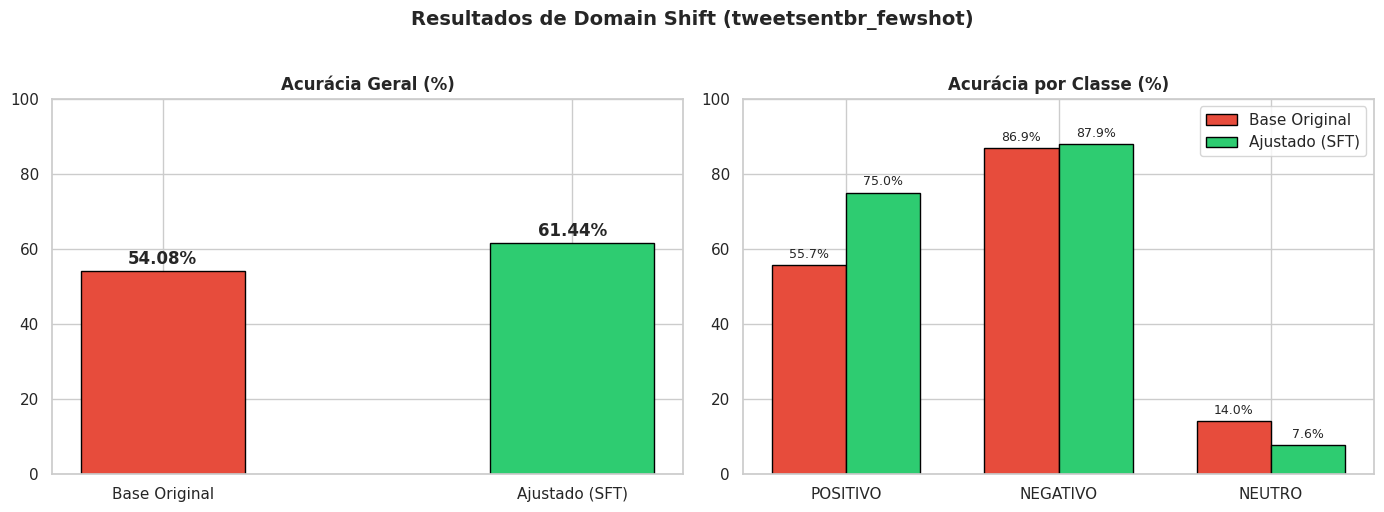

Gráfico salvo em: benchmark_domain_shift_results.png

TABELA COMPARATIVA DE ACURÁCIA
| Dataset / Modelo | Acurácia Geral | POSITIVO | NEGATIVO | NEUTRO |
| :--- | :---: | :---: | :---: | :---: |
| **Local - Base** | 59.66% | 82.58% | 91.29% | 5.11% |
| **Local - SFT** | 78.58% | 90.39% | 93.09% | 52.25% |
| **Domain Shift - Base** | 54.08% | 55.68% | 86.88% | 13.95% |
| **Domain Shift - SFT** | 61.44% | 74.97% | 87.90% | 7.56% |


In [5]:
# ======================================================================
# EXECUÇÃO DO BENCHMARK E GERAÇÃO DE GRÁFICOS
# ======================================================================

# 1. Executar Teste Local
df_test = pd.read_csv("datasets/test_final.csv")
prefix = 'Classifique o sentimento deste texto: "'
sentences_local = [
    u[len(prefix):-1] if u.startswith(prefix) and u.endswith('"') else u
    for u in df_test['user'].tolist()
]
labels_local = df_test['assistant'].tolist()
print("Iniciando Teste Local...")
base_local = evaluate_model(base_model_name, "Qwen 3.5 Base - Local", sentences_local, labels_local)
if ft_model_path:
    sft_local = evaluate_model(ft_model_path, "Qwen 3.5 SFT - Local", sentences_local, labels_local)
else:
    print("Ignorando teste do SFT local (modelo não carregado).")
    sft_local = {"overall_acc": 0.0, "class_acc": {"positivo": 0.0, "negativo": 0.0, "neutro": 0.0}}

# 2. Executar Teste de Domain Shift (eduagarcia/tweetsentbr_fewshot)
print("\nCarregando dataset de Domain Shift (tweetsentbr_fewshot) do Hugging Face...")
ds = load_dataset("eduagarcia/tweetsentbr_fewshot", split="test")
sentences_ds = ds["sentence"]
map_ds_sentiment = {
    0: "negativo", 1: "positivo", 2: "neutro",
    "Negative": "negativo", "Positive": "positivo", "Neutral": "neutro",
    "negative": "negativo", "positive": "positivo", "neutral": "neutro"
}
labels_ds = [map_ds_sentiment[l] for l in ds["label"]]

base_ds = evaluate_model(base_model_name, "Qwen 3.5 Base - Domain Shift", sentences_ds, labels_ds)
if ft_model_path:
    sft_ds = evaluate_model(ft_model_path, "Qwen 3.5 SFT - Domain Shift", sentences_ds, labels_ds)
else:
    sft_ds = {"overall_acc": 0.0, "class_acc": {"positivo": 0.0, "negativo": 0.0, "neutro": 0.0}}

# 3. Geração de Gráficos de Acurácia
def plot_comparison(base_res, sft_res, title, filename):
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1: Acurácia Geral
    models = ["Base Original", "Ajustado (SFT)"]
    accs = [base_res["overall_acc"] * 100, sft_res["overall_acc"] * 100]
    bars1 = axes[0].bar(models, accs, color=["#e74c3c", "#2ecc71"], width=0.4, edgecolor='black')
    axes[0].set_title("Acurácia Geral (%)", fontsize=12, fontweight='bold')
    axes[0].set_ylim(0, 100)
    for bar in bars1:
        yval = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.2f}%", ha='center', fontweight='bold')

    # Gráfico 2: Por classe
    classes = ["positivo", "negativo", "neutro"]
    base_c = [base_res["class_acc"][c] * 100 for c in classes]
    sft_c = [sft_res["class_acc"][c] * 100 for c in classes]

    x = np.arange(len(classes))
    width = 0.35

    bars2_base = axes[1].bar(x - width/2, base_c, width, label='Base Original', color="#e74c3c", edgecolor='black')
    bars2_sft = axes[1].bar(x + width/2, sft_c, width, label='Ajustado (SFT)', color="#2ecc71", edgecolor='black')

    axes[1].set_title("Acurácia por Classe (%)", fontsize=12, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([c.upper() for c in classes])
    axes[1].set_ylim(0, 100)
    axes[1].legend()

    for bar in bars2_base: axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{bar.get_height():.1f}%", ha='center', fontsize=9)
    for bar in bars2_sft: axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{bar.get_height():.1f}%", ha='center', fontsize=9)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Gráfico salvo em: {filename}")

# 4. Plotar e Exibir
plot_comparison(base_local, sft_local, "Resultados no Conjunto de Teste Local Balanceado", "benchmark_local_results.png")
plot_comparison(base_ds, sft_ds, "Resultados de Domain Shift (tweetsentbr_fewshot)", "benchmark_domain_shift_results.png")

# Tabela Resumo final
print("\n" + "="*60)
print("TABELA COMPARATIVA DE ACURÁCIA")
print("="*60)
print("| Dataset / Modelo | Acurácia Geral | POSITIVO | NEGATIVO | NEUTRO |")
print("| :--- | :---: | :---: | :---: | :---: |")
print(f"| **Local - Base** | {base_local['overall_acc']*100:.2f}% | {base_local['class_acc']['positivo']*100:.2f}% | {base_local['class_acc']['negativo']*100:.2f}% | {base_local['class_acc']['neutro']*100:.2f}% |")
print(f"| **Local - SFT** | {sft_local['overall_acc']*100:.2f}% | {sft_local['class_acc']['positivo']*100:.2f}% | {sft_local['class_acc']['negativo']*100:.2f}% | {sft_local['class_acc']['neutro']*100:.2f}% |")
print(f"| **Domain Shift - Base** | {base_ds['overall_acc']*100:.2f}% | {base_ds['class_acc']['positivo']*100:.2f}% | {base_ds['class_acc']['negativo']*100:.2f}% | {base_ds['class_acc']['neutro']*100:.2f}% |")
print(f"| **Domain Shift - SFT** | {sft_ds['overall_acc']*100:.2f}% | {sft_ds['class_acc']['positivo']*100:.2f}% | {sft_ds['class_acc']['negativo']*100:.2f}% | {sft_ds['class_acc']['neutro']*100:.2f}% |")
print("="*60)
